# Johnson and Shot Noise Analysis (2024)

#### This template assumes use of the new shot noise source

Use this template to carry out the analysis tasks for the Noise experiment.  For reference, here are links to recommended Python resources: the [Whirlwind Tour of Python](https://jakevdp.github.io/WhirlwindTourOfPython/) and the [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) both by Jake VanderPlas.
## First, import some packages

This is a good idea at the beginning of your notebook to include the packages that you will need.  We will use those shown below here.  A brief description:
* `numpy` is the foundational package for Python numerical work. It extends and speeds up array operations beyond standard Python, and it includes almost all math functions that you would need for example `sqrt()` (square root) or `cos()` (cosine).  These would be written in code as `np.sqrt()` or `np.cos()`.
* `scipy` is a huge collection of scientific data analysis functions, routines, physicical constants, etc.  This is the second most used package for scientific work. Here we will use the physical constants library, `scipy.constants`.  Documentation is at [SciPy.org](https://docs.scipy.org/doc/scipy/reference/) with the constants subpackage at https://docs.scipy.org/doc/scipy/reference/constants.html.
* `uncertainties` is a very useful small package that simplifies uncertainty propagation and printing out of quantities with uncertainty. Documentation is at https://pythonhosted.org/uncertainties/
* `matplotlib` is *the* standard plotting package for scientific Python.  We will use a subset called `pyplot` which is modeled after the plotting functions used in MATLAB. The last line below, `%matplotlib inline`, simply forces the plots to appear within the notebook.
* `pandas` is a large data science package.  It's main feature is a set of methods to create and manipulate a "DataFrame," which is an enlargement of the idea of an array.  I plays well with NumPy and other packages.  We will use it mainly as a way to read files into data sets in an easy way.

We will also use the [LMFit](https://lmfit.github.io/lmfit-py/) package to make line fits.  This will be explained later in the notebook.

In [69]:
# Run this cell with Shift-Enter, and wait until the 
# asterisk changes to a number, i.e., [*] becomes [1]
import numpy as np
import scipy.constants as const
import uncertainties as unc
import matplotlib.pyplot as plt
import pandas as pd
import uncertainties.unumpy as unp
%matplotlib inline

## Johnson Noise Analysis

## Exercise 1 -  Data reduction
### Read in the raw data

**About Data Files:** This template assumes that the data files will have one of two types of structure: 
1. If you took 5 readings (or so) for each measurement and plan to average them here, the assumed structure is one where each spreadsheet column is named with the resistance (for Johnson Noise), e.g., "9.99k", or the emission current (for shot noise), e.g., "0.1047mA" and each row of the data is one trial with each cell containing the measured RMS voltage in the frequency band; 
2. If you opted instead to simply take one longer-average time measurement for each resistance (or emission current), then the assumed structure would be two columns, the first column headed with resistance (or emission current) and the second column headed with the measured RMS voltage in the frequency band.

Below, these structures are treated by the designation "1" or "2".  Stucture type "1" requires a little more effort to reduce, but offers the option of calculating data point uncertainties. 

**Advice:** Use the **Pandas** function `read_csv()` to pull the file into a Pandas Dataframe, like this:

    johnson_294 = pd.read_csv('Johnson_294K.csv')

If the last line in the code cell is the name of the DataFrame (`johnson_294`), the notebook cell will print a nice table.

You may obtain the arrays for each column by using the column label, e.g., `johnson_294['40.0k']` is the array of the first column.

In [70]:
# Reading in CSV Data for T=295k and displaying it

johnson_295 = pd.read_csv('johnson295k_data.csv')
johnson_295 # Spits out a table

,0k,1k,2.5k,4.99k,7.5k,9.99k,15k,20k,40k
0,0.000595,0.001455,0.002152,0.003030,0.003675,0.003999,0.004977,0.005909,0.008006
1,0.000594,0.001460,0.002146,0.002975,0.003654,0.004175,0.005173,0.005821,0.008028
2,0.000611,0.001412,0.002181,0.003032,0.003725,0.004215,0.005086,0.005856,0.007930
3,0.000602,0.001432,0.002223,0.003000,0.003706,0.004178,0.005150,0.005880,0.007909
4,0.000600,0.001435,0.002076,0.002986,0.003596,0.004338,0.005076,0.005696,0.008014
5,0.000588,0.001477,0.002143,0.003037,0.003648,0.004101,0.005115,0.005754,0.008033


### Massage the raw data

#### For data structure type "1."  If you have a type "2" data structure, skip to "Plot the Reduced Data" below.

Create new arrays that have averages of the 5 readings at each value of the resistance and their standard deviation.  Then extract the resistance from the column label and make into a number.  Finally, build a new DataFrame that has these arrays. Below is an example.  The example shows a number of useful operations.  Study it carefully.

We will use a loop to build the new arrays first, and then combine them into a DataFrame.

You can extract the resistance from the column heading. Here is one way to do it, assuming `col_label` is the column label:

    resistance = float(col_label.split('k')[0])
    
This splits the label at `k` and puts the number into the first (0) position as a string.  `float()` converts the number string to a flaoting point number.

Then calculate the mean and standard deviation using the built-in methods for the arrays.

In [71]:
# Creating empty arrays that will be filled. 
Rs = np.zeros(0)
Vs = np.zeros(0)
Stds = np.zeros(0)

# Standard python loop
for label in johnson_295.columns:
    R = float(label.split('k')[0]) # Obtains the numerical part of column label
    mean = johnson_295[label].mean() # Calculates mean (average) of numbers in the column
    std = johnson_295[label].std() # Calculates the standard deviation of the same numbers

    # Following lines add the calculated results to associated array
    Rs = np.append(Rs,R)
    Vs = np.append(Vs,mean)
    Stds = np.append(Stds,std)

# Initialize an empty DataFrame
J_295 = pd.DataFrame()

# These lines add columns to the DataFrame
J_295['R (ohms)'] = Rs*1000.0 # Converts resistance from kohms to ohms
J_295['Vrms (V)'] = Vs
J_295['DV (V)'] = Stds

# Displays Results
J_295

,R (ohms),Vrms (V),DV (V)
0,0.0,0.000598,0.000008
1,1000.0,0.001445,0.000023
2,2500.0,0.002154,0.000049
3,4990.0,0.003010,0.000027
4,7500.0,0.003667,0.000046
5,9990.0,0.004168,0.000113
6,15000.0,0.005096,0.000069
7,20000.0,0.005819,0.000081
8,40000.0,0.007987,0.000053


#### Repeat for the other temperature 

Now you try it for the other temperature data set.

In [72]:
# Reading in CSV Data for T=77k and displaying it

johnson_77 = pd.read_csv('johnson77k_data.csv')
johnson_77 # Spits out a table

,0k,1k,2.5k,4.99k,7.5k,9.99k,15k,20k,40k (Band Vrms)
0,0.000625,0.000928,0.001239,0.001634,0.002058,0.002282,0.002727,0.003056,0.004390
1,0.000646,0.000928,0.001231,0.001672,0.002104,0.002244,0.002788,0.003225,0.004296
2,0.000640,0.000922,0.001250,0.001624,0.002092,0.002243,0.002700,0.003189,0.004372
3,0.000632,0.000933,0.001261,0.001660,0.002106,0.002170,0.002712,0.003183,0.004338
4,0.000635,0.000901,0.001235,0.001636,0.002150,0.002299,0.002752,0.003159,0.004280
5,0.000624,0.000926,0.001227,0.001692,0.002085,0.002281,0.002723,0.003202,0.004366


In [73]:
# Creating empty arrays that will be filled. 

Rs_77 = np.zeros(0)
Vs_77 = np.zeros(0)
Stds_77 = np.zeros(0)

# Standard python loop
for label in johnson_77.columns:
    R_77 = float(label.split('k')[0]) # Obtains the numerical part of column label
    mean_77 = johnson_77[label].mean() # Calculates mean (average) of numbers in the column
    std_77 = johnson_77[label].std() # Calculates the standard deviation of the same numbers

    # Following lines add the calculated results to associated array
    Rs_77 = np.append(Rs_77,R_77)
    Vs_77 = np.append(Vs_77,mean_77)
    Stds_77 = np.append(Stds_77,std_77)

# Initialize an empty DataFrame
J_77 = pd.DataFrame()

# These lines add columns to the DataFrame
J_77['R (ohms)'] = Rs_77*1000.0 # Converts resistance from kohms to ohms
J_77['Vrms (V)'] = Vs_77
J_77['DV (V)'] = Stds_77

# Displays Results
J_77

,R (ohms),Vrms (V),DV (V)
0,0.0,0.000634,0.000009
1,1000.0,0.000923,0.000011
2,2500.0,0.001241,0.000013
3,4990.0,0.001653,0.000026
4,7500.0,0.002099,0.000030
5,9990.0,0.002253,0.000046
6,15000.0,0.002734,0.000032
7,20000.0,0.003169,0.000059
8,40000.0,0.004340,0.000044


### Plot the reduced data

Plot the data set of $V_{rms}$ vs $R$ to see what it looks like.

Below, I'll show how. Study the commands, change them, and see what happens.  Hint: study the sections in the [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) on Matplotlib. 

After you make the plot, always look to make sure your data set does not have any weird points. This is a good way to catch bad data and/or mistakes.

In [74]:
# Set up plot defaults  This cell only needs to be executed once.
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = 10.0,8.0  # Roughly 11 cm wde by 8 cm high
mpl.rcParams['font.size'] = 12.0 # Use 12 point font

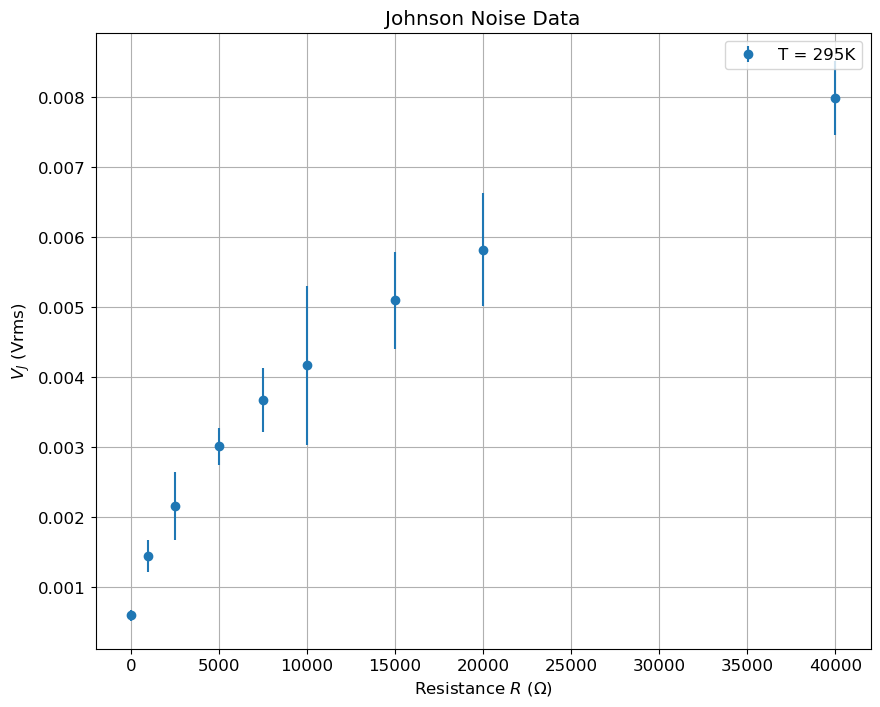

In [75]:
## Plot the data sets on one graph
## Header commands provided

plt.grid() # Turn on the grid
plt.title('Johnson Noise Data') # make a plot title
plt.ylabel(r'$V_J$ (Vrms)') # Make an axis label.  Note the $$ to typeset math
plt.xlabel(r'Resistance $R$ ($\Omega$)') #Another axis label

# Below shows how to make a plot with error bars.  The errors are multiplied by 
# 10 so that the bars are visible. 

# If you have no error bars, simply omit the item 'yerr=J_294['DV (V)']*10'

plt.errorbar(J_295['R (ohms)'],J_295['Vrms (V)'],
             yerr=J_295['DV (V)']*10,
             fmt='o',label='T = 295K')
plt.legend(); # Make a legend

### Include the other data

Repeat the lines in the cell above and include another data set so that both the 395K and 77K data are on the same plot.

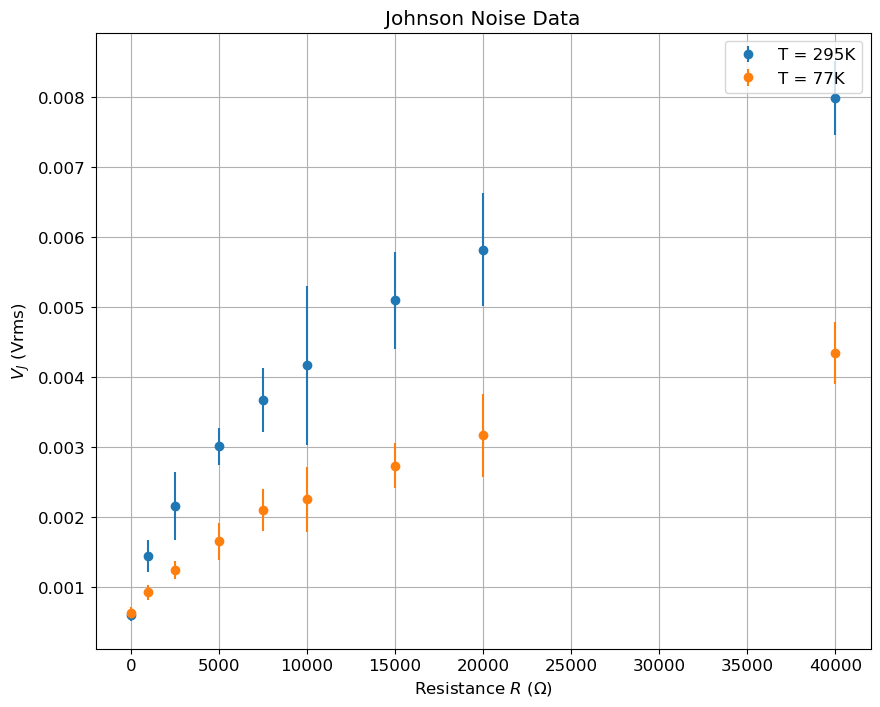

In [76]:
## You code this cell.

## Plot the data sets on one graph
## Header commands provided

# Plotting data set for both temperatures
plt.grid() # Turning on grid
plt.title('Johnson Noise Data') # Making title
plt.ylabel(r'$V_J$ (Vrms)') # Y axis label
plt.xlabel(r'Resistance $R$ ($\Omega$)') # X axis label

# Including error bars and scaling by 10
plt.errorbar(J_295['R (ohms)'],J_295['Vrms (V)'],
             yerr=J_295['DV (V)']*10,
             fmt='o',label='T = 295K')

# Including error bars and scaling by 10
plt.errorbar(J_77['R (ohms)'],J_77['Vrms (V)'],
             yerr=J_77['DV (V)']*10,
             fmt='o',label='T = 77K')

plt.legend(); # Make a legend

## Exercise 2

### Part a.  Modify the data

Modify the data arrays to obtain the mean square voltages for each temperature, and also the difference in the (squared) data for the two temperatures, which will help remove the effects of noise in the electronics.  **Remember:** You have NumPy/Pandas arrays, so you can do each task with a single line of code.

Then plot the results, all on one plot so you can compare them visually.

#### For data sets that have uncertainties associated with them. 

If you have uncertainties on each data point that you want to carry forward in the analysis, when you square the value, the uncertainty is NOT also squared. Instead it is multiplied by 2 times the |value|.  That is, if $\sigma_x$ is the uncertainty in $x$, the uncertainty in $x^2$ is $\sigma_{x^2} = 2|x|\sigma_x$. 

Another way to work out the uncertainties is to first build arrays of uncertainty objects from the data and uncertainty arrays. For example, if the data are in an array called `X` and the uncertainty (i.e., error bars) are in an array called `sigma_X`, you can build an uncertainty array as follows:

    # Import uNumPy functions.  You could do this in the first cell
    import uncertainties.unumpy as unp
    
    # Build an uncertainty array
    uX = unp.uarray(X, sigma_X)
    
    # Square the array, and also propagate uncertainty
    uX_sqrd = uX*uX
    
    # Access the parts of the uncertainty array.  This is necessary for curve fitting
    uX_sqrd_values = unp.nominal_values(uX_sqrd)
    uX_sqrd_sigmas = unp.std_devs(uX_sqrd)

In [77]:
## Modify the arrays as specified above

# Uncertainty arrays for 295K, 77K, 295K - 77K
uV_295 = unp.uarray(J_295['Vrms (V)'], J_295['DV (V)'])
uV_77 = unp.uarray(J_77['Vrms (V)'], J_77['DV (V)'])

# Modifying data
uV_sqrd_295 = uV_295 ** 2
uV_sqrd_77 = uV_77 ** 2
uV_sqrd_diff = uV_sqrd_295 - uV_sqrd_77

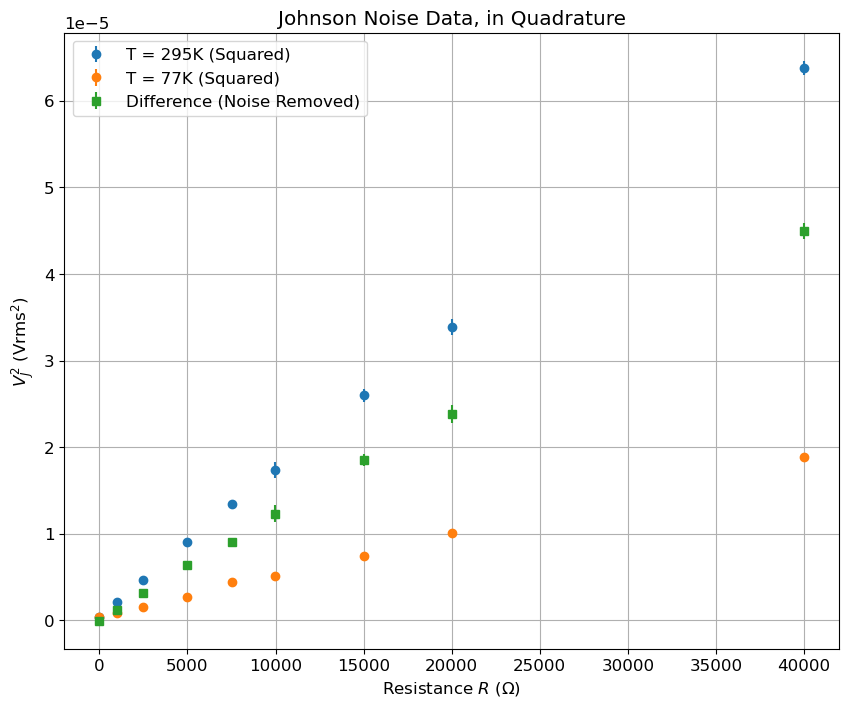

In [78]:
## Plot the results
## Header commands provided to format plot

plt.grid()
plt.title('Johnson Noise Data, in Quadrature')
plt.ylabel(r'$V^2_J$ (Vrms$^2$)')
plt.xlabel(r'Resistance $R$ ($\Omega$)')

# Grabbing x-axis data
x_axis = J_295['R (ohms)']

# Plotting
plt.errorbar(x_axis, 
             unp.nominal_values(uV_sqrd_295), 
             yerr=unp.std_devs(uV_sqrd_295), 
             fmt='o', label='T = 295K (Squared)')

plt.errorbar(x_axis, 
             unp.nominal_values(uV_sqrd_77), 
             yerr=unp.std_devs(uV_sqrd_77), 
             fmt='o', label='T = 77K (Squared)')

plt.errorbar(x_axis, 
             unp.nominal_values(uV_sqrd_diff), 
             yerr=unp.std_devs(uV_sqrd_diff), 
             fmt='s', label='Difference (Noise Removed)')

plt.legend();

### Part b. Fit the modified data

To fit the data set to a line, make use of the **LMFit** package. It is a useful add-on to the SciPy fitting functions.  This package simplifies fitting data to a variety of standard functions.  See the [Lmfit Documentation](https://lmfit.github.io/lmfit-py/index.html) for a full discussion.  The package is quite powerful, but for basic fitting with common functions, it is very easy to use.  

#### Example: Fitting a line

The example below shows how to use the package to fit data to a line, obtain the fit parameters along with uncertainties, and then plot the data and fit. Execute the cells and study how it works.
(Note: the data come from a calibration problem in physics 331)

In [79]:
# This cell only creates arrays of x and y data to feed to the fit example in the next cell.
# Calibration Data from a physics 331 experiment.
# First column is wavelength (nm), second is carriage position (cm)
#
Cal_data = np.array([
    [643.85, 41.43],
    [579.07, 37.24],
    [576.96, 37.11],
    [546.08, 35.10],
    [508.58, 32.68],
    [479.99, 30.83],
    [467.81, 30.04],
    [435.83, 27.96],
    [404.66, 25.98]])

# Array slicing separates x (position) and y (wavelength)
# Goal of calibration is to be able to feed in a position and obtain a wavelength
wavelength = Cal_data[:,0]
position = Cal_data[:,1]

The following cell executes the fitting calculations.

[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 4
    # data points      = 9
    # variables        = 2
    chi-square         = 0.18041902
    reduced chi-square = 0.02577415
    Akaike info crit   = -31.1872805
    Bayesian info crit = -30.7928313
    R-squared          = 0.99999620
[[Variables]]
    slope:      15.4639413 +/- 0.01139807 (0.07%) (init = 15.46394)
    intercept:  3.20598011 +/- 0.38164181 (11.90%) (init = 3.20598)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.9901


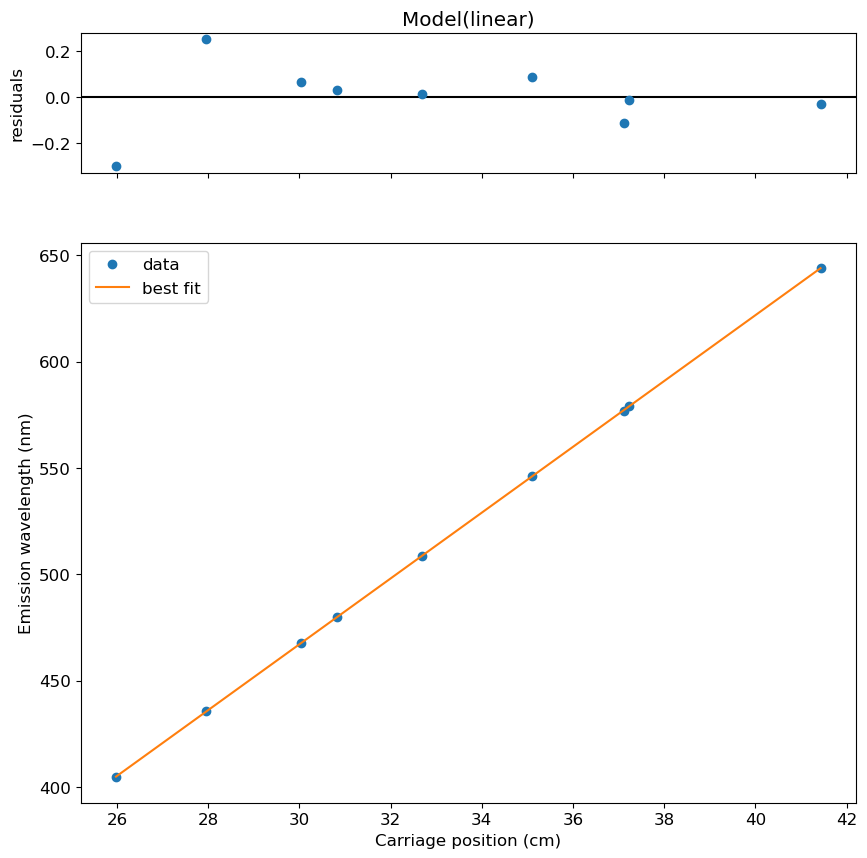

In [80]:
# imports a linear fitting model from lmfit  
# ONLY IMPORT ONCE IN A NOTEBOOK
from lmfit.models import LinearModel

# create an instance of the model
# You only need to do this once in a notebook
line = LinearModel()

# One must have a guess of the parameters. The guess() method works with most of the standard
# lmfit models

# The return value is a Parameters structure.  See the documentation.
param_guess = line.guess(wavelength, x=position)

# The line below executes the fitting process.  The results are returned to "line_fit"
line_fit = line.fit(wavelength, param_guess, x=position)

# This prints the results in an easy to read form
print(line_fit.fit_report())

#Then you can plot the results quickly just to see how it looks using the plot() method
line_fit.plot()
# Optional: Change axis labels from default 'X' vs. 'Y'.
plt.xlabel('Carriage position (cm)')
plt.ylabel('Emission wavelength (nm)');

Fit each to a line and obtain the slope with uncertainty.  Plot the data with the fit lines.

First, I'll make functions to clean up the coding.

In [81]:
## Defines a function to do the work.  Study it.  If you don't understand how this works,
## find out by asking questions and or studying the functions in the code.

def line_fit_and_plot(xdata, ydata, yerr=None, model=LinearModel(), xlabel='X', ylabel='Y'):
    '''
    Fit a line or curve, and plot/show the fit results.
    The function returns a parameters object with the fit parameters
    '''
    param_guess = model.guess(ydata, x=xdata)
    if (yerr is None):
        model_fit = model.fit(ydata, param_guess, x=xdata)
    else:
        model_fit = model.fit(ydata, param_guess, x=xdata, weights=1/yerr)
    print(model_fit.fit_report(show_correl=False))
    model_fit.plot()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel);
    return model_fit.params

## This function use the Uncertainties function to make an uncertainty object

def get_uslope(params):
    return unc.ufloat(params['slope'].value, params['slope'].stderr)

Then run the functions.

 LINEAR FIT FOR T = 295K 
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 2
    chi-square         = 25.3279637
    reduced chi-square = 3.61828053
    Akaike info crit   = 13.3121604
    Bayesian info crit = 13.7066096
    R-squared          = 0.99668057
[[Variables]]
    slope:      1.6629e-09 +/- 2.6834e-11 (1.61%) (init = 1.591656e-09)
    intercept:  3.6123e-07 +/- 1.7851e-08 (4.94%) (init = 1.095544e-06)

Slope (295K) = (1.663±0.027)×10⁻⁹



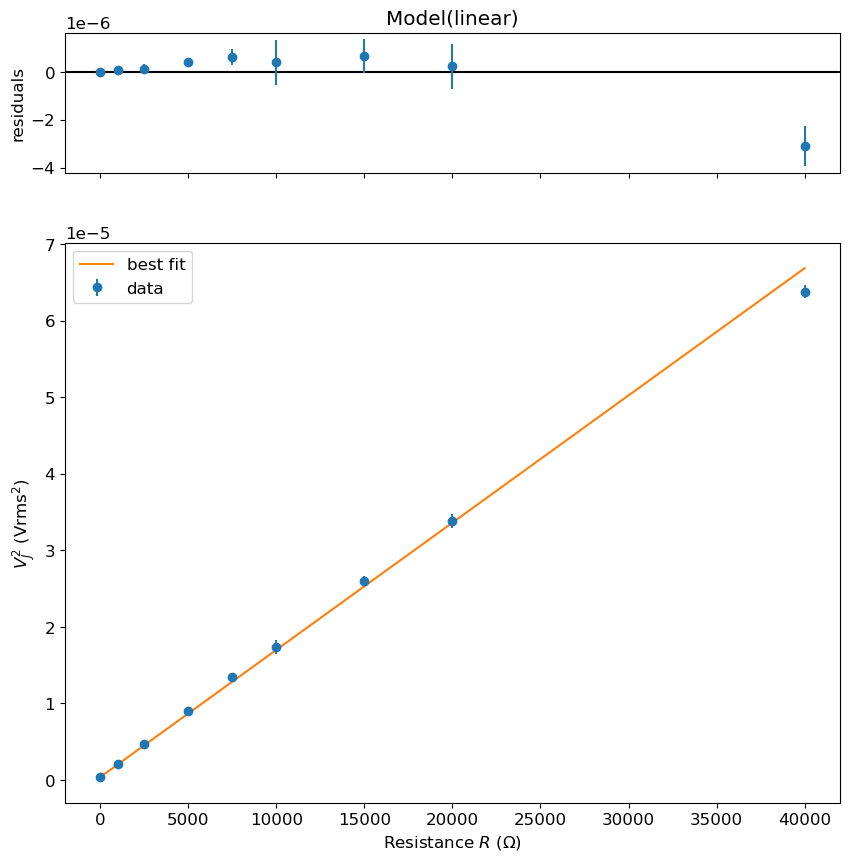

 LINEAR FIT FOR T = 77K 
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 2
    chi-square         = 17.5382783
    reduced chi-square = 2.50546833
    Akaike info crit   = 10.0044512
    Bayesian info crit = 10.3989004
    R-squared          = 0.99837390
[[Variables]]
    slope:      4.7136e-10 +/- 8.5049e-12 (1.80%) (init = 4.626628e-10)
    intercept:  3.9618e-07 +/- 1.5243e-08 (3.85%) (init = 5.158074e-07)

Slope (77K) = (4.714±0.085)×10⁻¹⁰



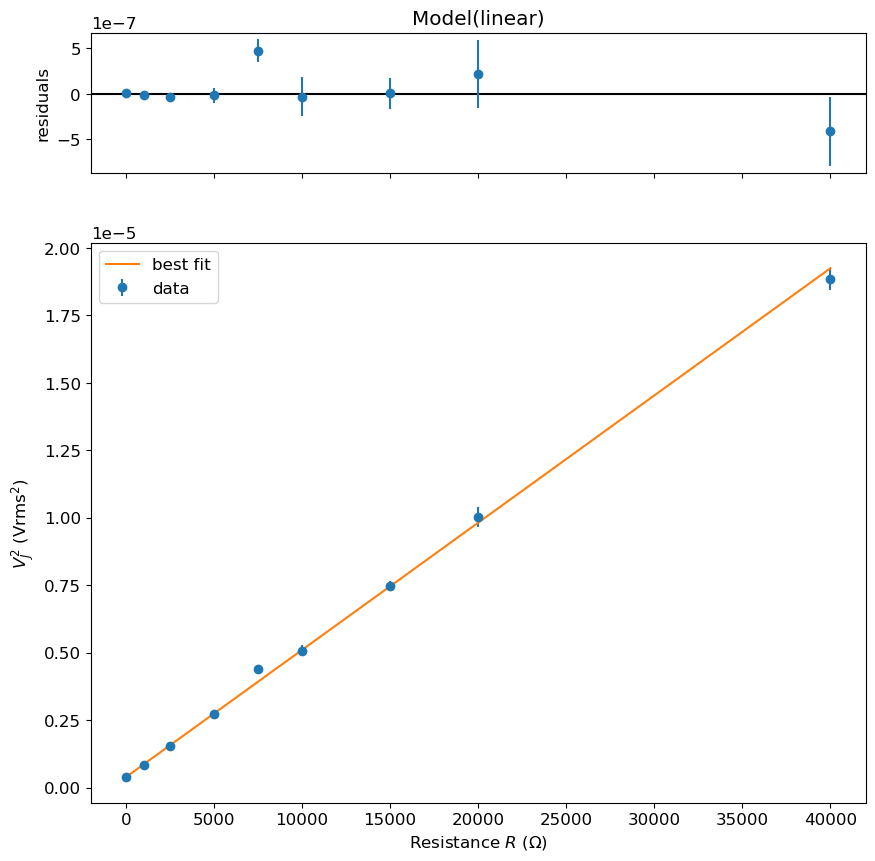

 LINEAR FIT FOR SQUARED DIFFERENCE 
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 2
    chi-square         = 16.8344616
    reduced chi-square = 2.40492309
    Akaike info crit   = 9.63583144
    Bayesian info crit = 10.0302806
    R-squared          = 0.99514541
[[Variables]]
    slope:      1.1911e-09 +/- 2.3853e-11 (2.00%) (init = 1.128993e-09)
    intercept: -3.6755e-08 +/- 2.1888e-08 (59.55%) (init = 5.797365e-07)

Slope (Difference) = (1.191±0.024)×10⁻⁹



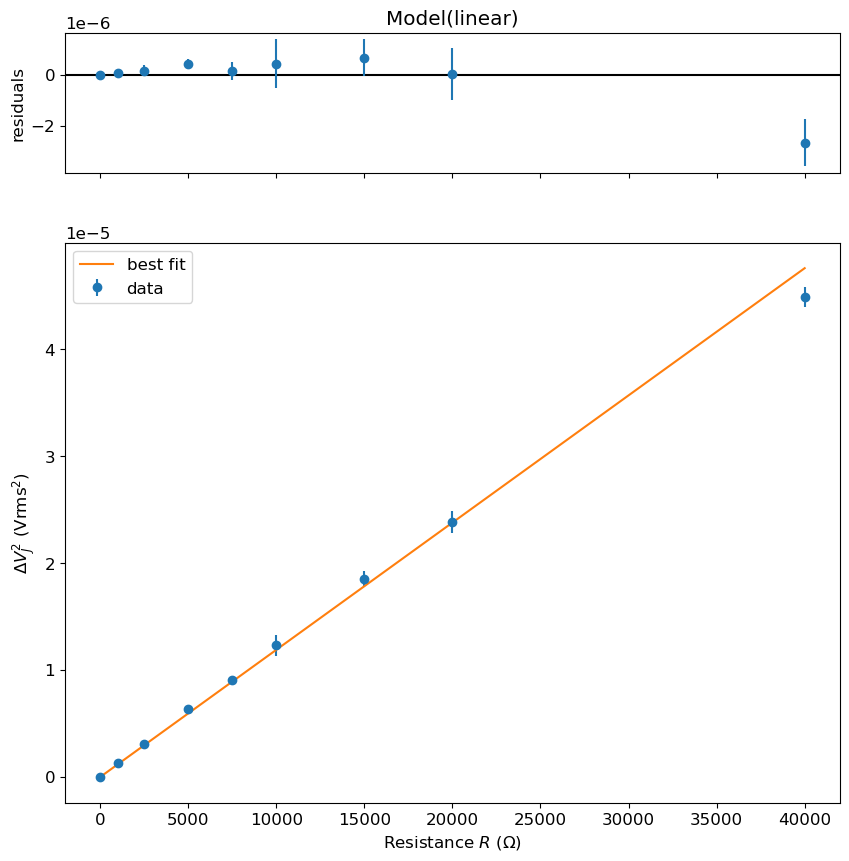

In [82]:
## Use the functions above to run the fit for the modified 295K data
## and save the fit parameters.  Then pull out the slope
x_data = J_295['R (ohms)'] # x-axis for all fits

# 295K Data
y_295_vals = unp.nominal_values(uV_sqrd_295)
y_295_errs = unp.std_devs(uV_sqrd_295)

# 77K Data
y_77_vals = unp.nominal_values(uV_sqrd_77)
y_77_errs = unp.std_devs(uV_sqrd_77)

# Difference Data
y_diff_vals = unp.nominal_values(uV_sqrd_diff)
y_diff_errs = unp.std_devs(uV_sqrd_diff)

# Fitting for T = 295K
print(" LINEAR FIT FOR T = 295K ")
params_295 = line_fit_and_plot(x_data, y_295_vals, yerr=y_295_errs,
                               xlabel=r'Resistance $R$ ($\Omega$)',
                               ylabel=r'$V^2_J$ (Vrms$^2$)')
slope_295 = get_uslope(params_295)
print('\nSlope (295K) = {:.2uP}\n'.format(slope_295))
plt.show() # Forces the plot to render clearly before starting the next text block

# Fitting for T = 77K
print(" LINEAR FIT FOR T = 77K ")
params_77 = line_fit_and_plot(x_data, y_77_vals, yerr=y_77_errs,
                              xlabel=r'Resistance $R$ ($\Omega$)',
                              ylabel=r'$V^2_J$ (Vrms$^2$)')
slope_77 = get_uslope(params_77)
print('\nSlope (77K) = {:.2uP}\n'.format(slope_77))
plt.show()

# Fitting for Difference
print(" LINEAR FIT FOR SQUARED DIFFERENCE ")
params_diff = line_fit_and_plot(x_data, y_diff_vals, yerr=y_diff_errs,
                                xlabel=r'Resistance $R$ ($\Omega$)',
                                ylabel=r'$\Delta V^2_J$ (Vrms$^2$)')
slope_diff = get_uslope(params_diff)
print('\nSlope (Difference) = {:.2uP}\n'.format(slope_diff))
plt.show()

### Calculate a Boltzmann constant

From the results, calculate the implied Boltzmann constant (with uncertainty).

Revised gain of low-noise amplifier $G=10122\pm35$ (as of July 2021, DBP)

In [84]:
## Create uncertainties objects for the other quantities.  The first two are examples
T_295 = unc.ufloat(295.0,1.0) # K
G = unc.ufloat(10122,35) # unitless
k_B = const.Boltzmann # J/K Accepted value of Boltsmann constant from SciPy constants library.
# You do the rest

T_77 = unc.ufloat(77.0, 1.0)    # K

# Defining bandwidth in Hz
delta_f = unc.ufloat(1000, 0)   # 1000 Hz bandwidth 

# 295K Data
# k = Slope / (4 * T * delta_f * G^2)
k_295 = slope_295 / (4 * T_295 * delta_f * (G ** 2))

print(' Boltzmann Constant from 295K Data ')
print('Boltzmann constant from T = 295K data = {:.2uP} J/K'.format(k_295))
print('Accepted value = {:.4g} J/K\n'.format(k_B))

 Boltzmann Constant from 295K Data 
Boltzmann constant from T = 295K data = (1.376±0.025)×10⁻²³ J/K
Accepted value = 1.381e-23 J/K



### 77 K data
Repeat the process for the 77K data set.

In [85]:
## Repeat for the 77K data

T_295 = unc.ufloat(295.0,1.0) # K
G = unc.ufloat(10122,35) # unitless
k_B = const.Boltzmann # J/K Accepted value of Boltsmann constant from SciPy constants library.
# You do the rest

T_77 = unc.ufloat(77.0, 1.0)    # K

# Defining bandwidth in Hz
delta_f = unc.ufloat(1000, 0)   # 1000 Hz bandwidth 

# 77K Data
k_77 = slope_77 / (4 * T_77 * delta_f * (G ** 2))

print(' Boltzmann Constant from 77K Data ')
print('Boltzmann constant from T = 77K data = {:.2uP} J/K'.format(k_77))
print('Accepted value = {:.4g} J/K\n'.format(k_B))

 Boltzmann Constant from 77K Data 
Boltzmann constant from T = 77K data = (1.494±0.035)×10⁻²³ J/K
Accepted value = 1.381e-23 J/K



And finally, the difference data

In [86]:
## Repeat for the "difference" data (295K-77K) subracted in quadrature

T_295 = unc.ufloat(295.0,1.0) # K
G = unc.ufloat(10122,35) # unitless
k_B = const.Boltzmann # J/K Accepted value of Boltsmann constant from SciPy constants library.
# You do the rest

T_77 = unc.ufloat(77.0, 1.0)    # K

# Defining bandwidth in Hz
delta_f = unc.ufloat(1000, 0)   # 1000 Hz bandwidth 

# Difference Data
dT = T_295 - T_77
k_diff = slope_diff / (4 * dT * delta_f * (G ** 2))

print(' Boltzmann Constant from Difference Data ')
print('Boltzmann constant from Difference data = {:.2uP} J/K'.format(k_diff))
print('Accepted value = {:.4g} J/K'.format(k_B))

 Boltzmann Constant from Difference Data 
Boltzmann constant from Difference data = (1.333±0.030)×10⁻²³ J/K
Accepted value = 1.381e-23 J/K


### Plot everything on one graph

Make a single plot that shows all three sets of data (as points) and the three fit lines (as lines).  Include a legend.

The cell below shows how to create a fit line using an arbitrary set of x-values based on the range of x data.  It uses the example data sets.

In [87]:
## Create a "fit line" based on the obtained fit parameters

# Set of 100 evenly-spaced points
x_fit_lines = np.linspace(x_data.min(), x_data.max(), 100)

# Evaluating linear models using parameter objects from fits
y_fit_295  = line.eval(params_295, x=x_fit_lines)
y_fit_77   = line.eval(params_77, x=x_fit_lines)
y_fit_diff = line.eval(params_diff, x=x_fit_lines)

OK, it is your turn.

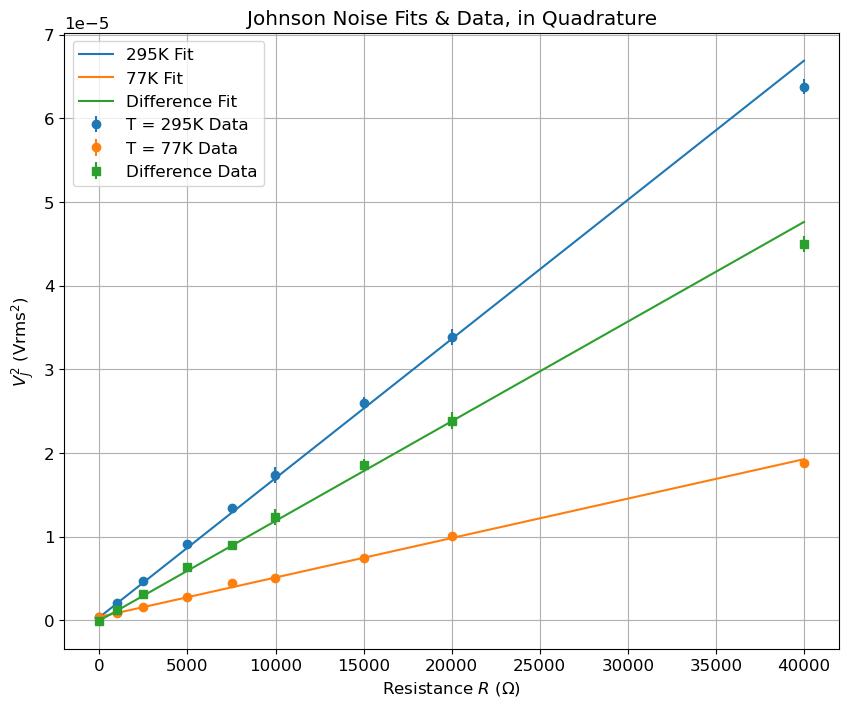

In [88]:
# Plot title
plt.grid()
plt.title('Johnson Noise Fits & Data, in Quadrature')
plt.ylabel(r'$V^2_J$ (Vrms$^2$)')
plt.xlabel(r'Resistance $R$ ($\Omega$)')

# Plotting data points w/ uncertainties
plt.errorbar(x_data, y_295_vals, yerr=y_295_errs, fmt='o', color='C0', label='T = 295K Data')
plt.errorbar(x_data, y_77_vals, yerr=y_77_errs, fmt='o', color='C1', label='T = 77K Data')
plt.errorbar(x_data, y_diff_vals, yerr=y_diff_errs, fmt='s', color='C2', label='Difference Data')

# Plotting best fit lines

plt.plot(x_fit_lines, y_fit_295, '-', color='C0', label='295K Fit')
plt.plot(x_fit_lines, y_fit_77, '-', color='C1', label='77K Fit')
plt.plot(x_fit_lines, y_fit_diff, '-', color='C2', label='Difference Fit')

plt.legend()
plt.show()

### Part c.

Summary of results for Boltsmann constant:

In [89]:
# Summarizing results in one table
print('  T (K)  |  k_B (J/K)   ')
print('---------|--------------------')
print('   295   | {:.1uP}'.format(k_295))
print('    77   | {:.1uP}'.format(k_77))
print(' 295-77  | {:.1uP}'.format(k_diff))
print('Accepted | {:10.4g}'.format(k_B))

  T (K)  |  k_B (J/K)   
---------|--------------------
   295   | (1.38±0.02)×10⁻²³
    77   | (1.49±0.03)×10⁻²³
 295-77  | (1.33±0.03)×10⁻²³
Accepted |  1.381e-23


## Exercise 3: Noise Figure

Calculate the "noise figure" for the low-noise amp, as described in the instructions.

The noise figure is defined:

$$ NF = 20\log_{10}\frac{V_{rms}(R)}{G\times\sqrt{4k_BTRB}} \; \text{dB}$$

Please limit the noise figure to 2 digits beyond the decimal point.  

Note: It clearly does not work for $R=0$.  You will need to leave this out of the calculations.

 Noise Figure Table 


,R (ohms),Noise Figure (dB)
1,1000.0,0.97
2,2500.0,0.46
3,4990.0,0.37
4,7500.0,0.31
5,9990.0,0.18
6,15000.0,0.16
7,20000.0,0.06
8,40000.0,-0.20


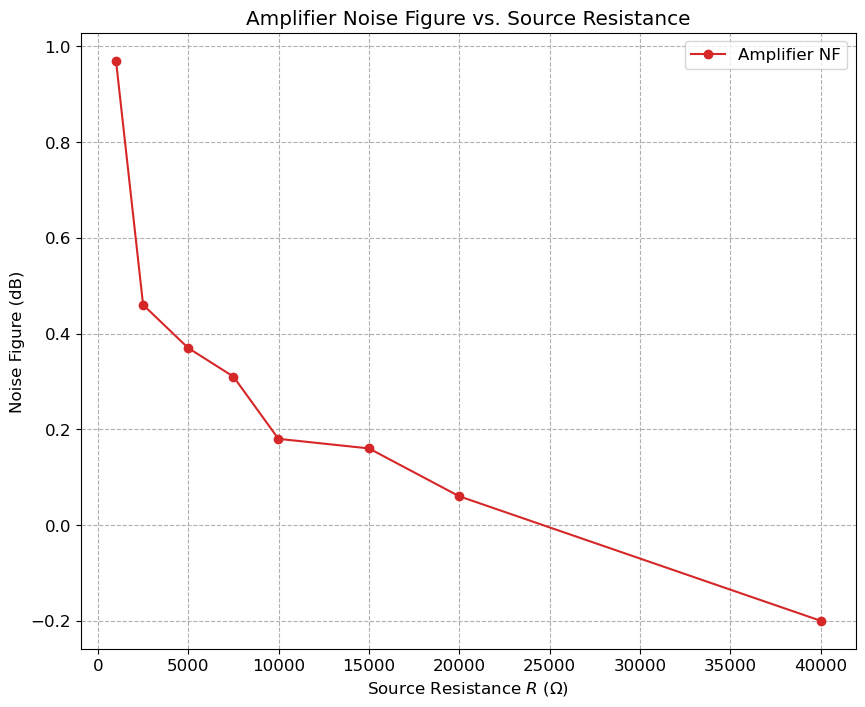

In [90]:
## Calculate the Noise figure for the various values of R at 
## room temperature and display it as a table or a plot

## Make a data frame to display

# Creating dataframe ommiting zero resistance to avoid division by zero errors
NF_data = J_295[J_295['R (ohms)'] > 0].copy()

# Getting nominal values for uncertainties
T_val = T_295.nominal_value      # 295 K
G_val = G.nominal_value          # 10122
B_val = delta_f.nominal_value    # 1000 Hz

# Calculating voltage at output of amplifier 
# V_output = G * sqrt(4 * k_B * T * R * B)
R_vals = NF_data['R (ohms)']
V_output = G_val * np.sqrt(4 * k_B * T_val * R_vals * B_val)

# Calculating output voltage in volts
V_measured_volts = NF_data['Vrms (V)']

# Computing in dB
NF_data['Noise Figure (dB)'] = np.round(20 * np.log10(V_measured_volts / V_output), 2)

# Displaying as a dataframe
print(" Noise Figure Table ")

display(NF_data[['R (ohms)', 'Noise Figure (dB)']])

# Plotting Noise Figure vs Resistance
plt.figure()
plt.grid(True, which="both", ls="--") 
plt.plot(NF_data['R (ohms)'], NF_data['Noise Figure (dB)'], 'o-', color='C3', label='Amplifier NF')

plt.title('Amplifier Noise Figure vs. Source Resistance')
plt.xlabel(r'Source Resistance $R$ ($\Omega$)')
plt.ylabel('Noise Figure (dB)')
plt.legend()
plt.show()

## Shot Noise Analysis

This is very similar to the Johnson noise analysis.

### Read in the data

For data structure type "1", column names like "0.1202mA" need to split at `m` to convert the current labels into currents.

In [91]:
## Read in the shot noise data and display it
shot_data = pd.read_csv('current_data.csv')
shot_data

,0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.11,0.12,0.13,0.14,0.15
0,0.005507,0.007805,0.009788,0.01142,0.01307,0.01575,0.01606,0.01693,0.01702,0.01876,0.01935,0.02043,0.02105,0.02188,0.02237,0.02327
1,0.005424,0.007955,0.010020,0.01204,0.01324,0.01592,0.01525,0.01712,0.01694,0.01824,0.01883,0.01994,0.02070,0.02140,0.02208,0.02326
2,0.005614,0.008461,0.010260,0.01271,0.01338,0.01452,0.01579,0.01621,0.01721,0.01841,0.01923,0.01973,0.02031,0.02198,0.02212,0.02268
3,0.005363,0.008876,0.009930,0.01306,0.01273,0.01594,0.01521,0.01668,0.01700,0.01825,0.01903,0.02012,0.02078,0.02201,0.02261,0.02376
4,0.005386,0.008002,0.009877,0.01288,0.01340,0.01469,0.01536,0.01644,0.01687,0.01818,0.01867,0.02014,0.02113,0.02202,0.02194,0.02240
5,0.005163,0.008369,0.010040,0.01163,0.01294,0.01595,0.01537,0.01631,0.01781,0.01926,0.01949,0.02017,0.02065,0.02172,0.02235,0.02387


### Obtain averages

For Data structure type "1" only

In [92]:
## Calculate the averages and extract the values of the emission current.  
## Display the results to check.

shot_averages_check = pd.DataFrame()
shot_averages_check['Extracted Current (A)'] = J_shot['I (A)']
shot_averages_check['Average Vrms (V)'] = J_shot['Vrms (V)']
shot_averages_check['Voltage Uncertainty DV (V)'] = J_shot['DV (V)']

# Displaying
print(" Shot Noise Extraction & Averages Check ")
display(shot_averages_check)

 Shot Noise Extraction & Averages Check 


,Extracted Current (A),Average Vrms (V),Voltage Uncertainty DV (V)
0,0.00000,0.005410,0.000152
1,0.00001,0.008245,0.000399
2,0.00002,0.009986,0.000163
3,0.00003,0.012290,0.000689
4,0.00004,0.013127,0.000263
5,0.00005,0.015462,0.000670
6,0.00006,0.015507,0.000341
7,0.00007,0.016615,0.000359
8,0.00008,0.017142,0.000347
9,0.00009,0.018517,0.000421


### Plot the raw data

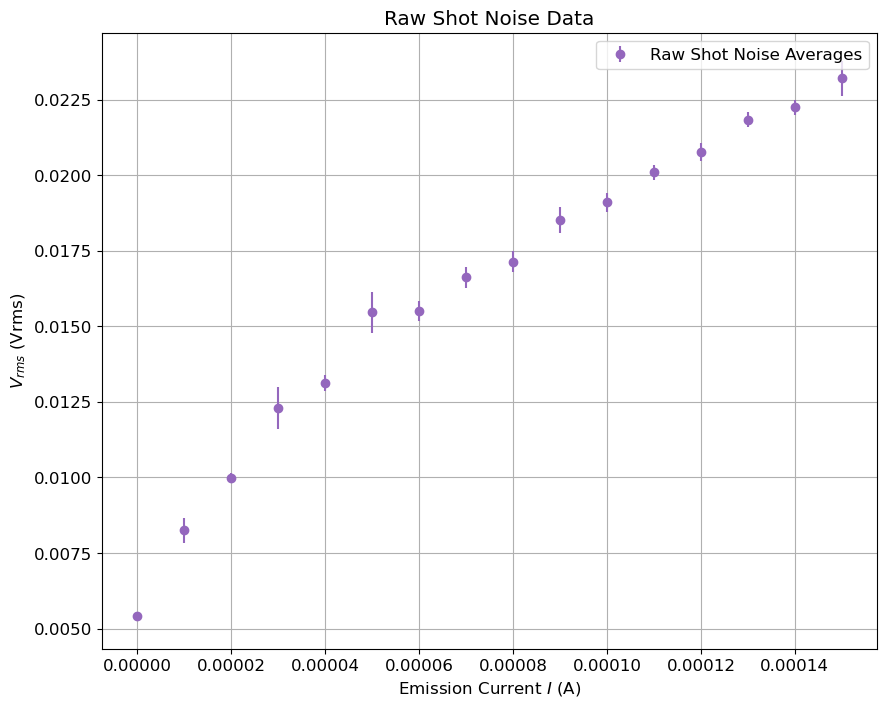

In [93]:
## Plot it
plt.grid()
plt.title('Raw Shot Noise Data')
plt.ylabel(r'$V_{rms}$ (Vrms)')
plt.xlabel('Emission Current $I$ (A)')

# Plotting vales 
plt.errorbar(J_shot['I (A)'], J_shot['Vrms (V)'], 
             yerr=J_shot['DV (V)'], 
             fmt='o', color='C4', label='Raw Shot Noise Averages')

plt.legend()
plt.show()

### Calculate $V^2_{rms}$

In [94]:
## transform the data, like you did with Johnson noise
# Uncertainty arrays combining nominal raw values and errors
uV_shot = unp.uarray(J_shot['Vrms (V)'], J_shot['DV (V)'])

# Transforming data via squaring
uV_sqrd_shot = uV_shot ** 2

uV_sqrd_shot_values = unp.nominal_values(uV_sqrd_shot)
uV_sqrd_shot_sigmas = unp.std_devs(uV_sqrd_shot)

# Printing samples to confirm process worked
print("First 5 squared voltage values:", uV_sqrd_shot_values[:5])
print("First 5 propagated uncertainties:", uV_sqrd_shot_sigmas[:5])

First 5 squared voltage values: [2.92626903e-05 6.79745284e-05 9.97168674e-05 1.51044100e-04
 1.72309378e-04]
First 5 propagated uncertainties: [1.64087889e-06 6.58311241e-06 3.26179365e-06 1.69313206e-05
 6.91747519e-06]


### Then fit it and plot it

**Note:** Shot nose data may not be "pure" in that you will see a notable deviation from the expected behavior.  The data may be affected by $1/f$ noise in the vacuum diode that gets worse with higher emission current.   This effect is reduced in the newer shot noise apparatus that uses a different vacuum diode.  If you see a notable curve in your measured voltage, you may try a couple of work-arounds to obtain the linear part of the noise-squared vs emission current:

1. Select a portion of the data to fit, where the $1/f$ problem is less, near the low-emission current end of the data set.
2. Make a ploynomial fit and look at the linear term.

You should try a couple of options and compare your results with your partners.  You only need to do this if you see the $1/f$ effect.

 SHOT NOISE LINEAR FIT: FULL DATASET 
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 16
    # variables        = 2
    chi-square         = 9.66359556
    reduced chi-square = 0.69025683
    Akaike info crit   = -4.06756691
    Bayesian info crit = -2.52238946
    R-squared          = 0.99369318
[[Variables]]
    slope:      3.40007662 +/- 0.03156605 (0.93%) (init = 3.298766)
    intercept:  3.0365e-05 +/- 1.2219e-06 (4.02%) (init = 4.149815e-05)

Full Dataset Slope = 3.400±0.032



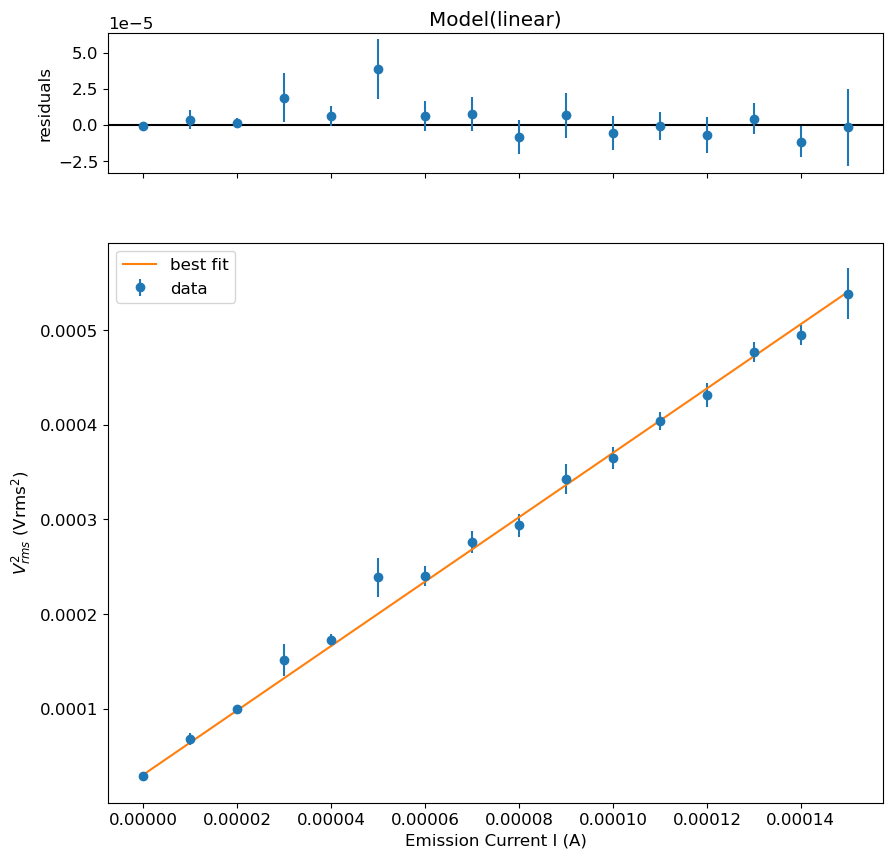

In [95]:
## First the fit. Try the whole data set first.

# Extracting x-axis of emission current 
x_shot = J_shot['I (A)']

# Fit for the whole dataset
print(" SHOT NOISE LINEAR FIT: FULL DATASET ")
params_shot_full = line_fit_and_plot(
    x_shot, 
    uV_sqrd_shot_values, 
    yerr=uV_sqrd_shot_sigmas,
    xlabel='Emission Current I (A)', 
    ylabel=r'$V^2_{rms}$ (Vrms$^2$)'
)
slope_shot_full = get_uslope(params_shot_full)
print('\nFull Dataset Slope = {:.2uP}\n'.format(slope_shot_full))
plt.show()

 SHOT NOISE LINEAR FIT: LOWER HALF DATASET 
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 8
    # variables        = 2
    chi-square         = 3.46805069
    reduced chi-square = 0.57800845
    Akaike info crit   = -2.68679092
    Bayesian info crit = -2.52790784
    R-squared          = 0.97843129
[[Variables]]
    slope:      3.57593157 +/- 0.07066751 (1.98%) (init = 3.60629)
    intercept:  2.9331e-05 +/- 1.1831e-06 (4.03%) (init = 3.326555e-05)

Lower Half Dataset Slope = 3.576±0.071



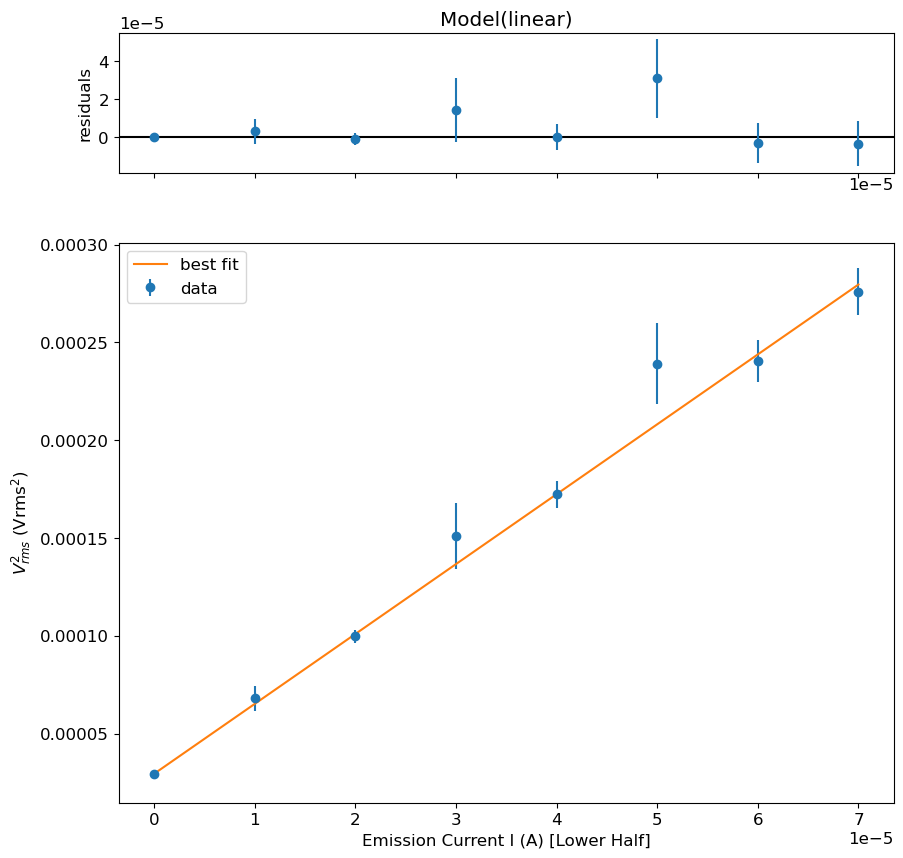

In [96]:
## Then try the lower half of the data, before the 1/f takes over, if necessary

# Calculating points making up half the dataset
half_points = len(x_shot) // 2

# Fit for the lower half of the dataset
x_shot_half = x_shot[:half_points]
y_shot_half_vals = uV_sqrd_shot_values[:half_points]
y_shot_half_errs = uV_sqrd_shot_sigmas[:half_points]

print(" SHOT NOISE LINEAR FIT: LOWER HALF DATASET ")
params_shot_half = line_fit_and_plot(
    x_shot_half, 
    y_shot_half_vals, 
    yerr=y_shot_half_errs,
    xlabel='Emission Current I (A) [Lower Half]', 
    ylabel=r'$V^2_{rms}$ (Vrms$^2$)'
)
slope_shot_half = get_uslope(params_shot_half)
print('\nLower Half Dataset Slope = {:.2uP}\n'.format(slope_shot_half))
plt.show()

Optional: Another way out of the $1/f$ problem is to fit a quadratic, and use the linear-term coefficient as the initial slope.

In [97]:
## To do this, you need a different fitting model
#  Below will get you started, but you need to study the docs to understand the parameters.

from lmfit.models import QuadraticModel
quadratic = QuadraticModel()

## You do the rest

In [98]:
## Now make a nice plot of all fits over the data points



### Calculate Electron Charge

Use the fit results, propagate the uncertainty, and find a value for $e$.

In [100]:
## Calculate e with uncertainty and print it (with units) 
## Compare with the accepted value

# You will need the correct sensing resistance in the shot noise box:
# Older box:
# R_load = unc.ufloat(4976,1) # Load resistance of shot noise box in ohms 
# Newer box:
# R_load = unc.ufloat(10000.0,10)

# Calculate the result, and propagate the uncertainty.

# Use whatever you need below
# print('\nElectron charge from whole data set = {:.2uP} C'.format(e_1))
# print('Electron charge from partial data set = {:.2uP} C'.format(e_2))
# print('Electron charge from quadratic fit = {:.2uP} C'.format(e_3))
# print('\nAccepted value = {:.4g} C'.format(const.e))


# Parameters and Uncertainties
G = unc.ufloat(10122, 35)        # Amplifier gain
delta_f = unc.ufloat(1000, 0)    # Bandwidth in Hz

# Apparatus load resistor and uncertainty 1%
R_load = unc.ufloat(10000.0, 100)

# e = slope / (2 * delta_f * R_load^2 * G^2)
e_1 = slope_shot_full / (2 * delta_f * (R_load ** 2) * (G ** 2)) # Whole dataset calculation

e_2 = slope_shot_half / (2 * delta_f * (R_load ** 2) * (G ** 2)) # Lower-half of dataset calculation

# Comparing results
print(' Experimental Electron Charge Results ')
print('Electron charge from whole data set = {:.2uP} C'.format(e_1))
print('Electron charge from partial data set = {:.2uP} C'.format(e_2))

# Displaying true constant value for comparision
print('\nAccepted value = {:.4g} C'.format(const.e))

 Experimental Electron Charge Results 
Electron charge from whole data set = (1.659±0.038)×10⁻¹⁹ C
Electron charge from partial data set = (1.745±0.051)×10⁻¹⁹ C

Accepted value = 1.602e-19 C


## Optional Exercise: $1/f$ noise

Measurements of the power spectral density in units of $V/\sqrt{\text{Hz}}$ were made from the "1/f noise source", along with the same values from the amplifier alone.  The curve shows a 1/f spectrum where $V^2 \propto 1/f^\alpha$.  In this exercise, one determines the exponent $\alpha$.

The data are in a file called `one_over_f_noise_data.csv`.  The first line of the data file must be skipped.  (Look at it to see why.)

In [101]:
## Read in the data


In [102]:
## Do the "subtract by quadrature" game to remove the mostly constant background.

## Convienence: pull out the frequency array


In [103]:
## Make a plot  Use log axes to see a line


In [104]:
## Fit a line to the log_10 of the data vs log_10 of the frequency.
## The slope will be -alpha.


In [105]:
## Extract the exponent from the fit

# print('1/f noise exponent = {:.1uP}'.format(alpha))